# Fase 1 (API) - Analisis Exploratorio de Datos (EDA)

**Proyecto:** Priorizacion de brigadas de salud extramurales para comunidades indigenas y rurales dispersas de Colombia.

**Objetivo:** cargar el dataset final (municipio x anio), describirlo, visualizar sus variables y detectar problemas de calidad (nulos, outliers, desbalance de clases, consistencia) para preparar la fase de modelado.

**Fuente:** `data/modelo/municipio_anio.csv` (5.610 filas x 57 columnas; 1.122 municipios x 2017-2021).

> Ejecuta las celdas en orden (en Colab: *Entorno de ejecucion -> Ejecutar todas*). Si saltas la celda de carga, `df` no existira y veras un `NameError`.

## 0. Configuracion

In [21]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

print('Librerias cargadas correctamente')
print('pandas', pd.__version__, '| matplotlib', matplotlib.__version__, '| seaborn', sns.__version__)

Librerias cargadas correctamente
pandas 2.3.3 | matplotlib 3.11.2 | seaborn 0.13.2


## 1. Carga y descripcion del dataset

En Google Colab, ejecuta esta celda: si el archivo no esta en el directorio de trabajo, te pedira subir `municipio_anio.csv`.

In [22]:
RUTA = None

candidatos = [p for p in
              ['data/modelo/municipio_anio.csv', 'municipio_anio.csv',
               'output/municipio_anio.csv', '../data/modelo/municipio_anio.csv']
              if os.path.exists(p)]
candidatos += glob.glob('**/municipio_anio.csv', recursive=True)

if candidatos:
    RUTA = candidatos[0]
else:
    try:
        from google.colab import files
        print('Sube el archivo municipio_anio.csv...')
        subidos = files.upload()
        csvs = [n for n in subidos if n.lower().endswith('.csv')]
        if not csvs:
            raise RuntimeError('No se subio ningun archivo CSV.')
        RUTA = csvs[0]
    except ImportError as exc:
        raise FileNotFoundError('No se encontro municipio_anio.csv. Ejecuta primero el pipeline en src/.') from exc

df = pd.read_csv(RUTA, encoding='utf-8-sig', dtype={'cod_mpio': str, 'cod_dpto': str})

print('Archivo cargado:', RUTA)
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])

Archivo cargado: data/modelo/municipio_anio.csv
Filas: 5610
Columnas: 57


In [23]:
print('Tipos de datos por columna:')
print(df.dtypes.to_string())

print()
print('Primeras 5 filas:')
df.head()

Tipos de datos por columna:
cod_mpio                      object
cod_dpto                      object
nom_mpio                      object
a_o                            int64
banda_pob                      int64
consultas                      int64
hospitalizaciones              int64
procedimientos                 int64
urgencias                      int64
atenciones_total               int64
sin_rips                        bool
pct_cap_A                    float64
pct_cap_B                    float64
pct_cap_C                    float64
pct_cap_D                    float64
pct_cap_E                    float64
pct_cap_F                    float64
pct_cap_G                    float64
pct_cap_H                    float64
pct_cap_I                    float64
pct_cap_J                    float64
pct_cap_K                    float64
pct_cap_L                    float64
pct_cap_M                    float64
pct_cap_N                    float64
pct_cap_O                    float64
pct_cap_P 

,cod_mpio,cod_dpto,nom_mpio,a_o,banda_pob,consultas,hospitalizaciones,procedimientos,urgencias,atenciones_total,sin_rips,pct_cap_A,pct_cap_B,pct_cap_C,pct_cap_D,pct_cap_E,pct_cap_F,pct_cap_G,pct_cap_H,pct_cap_I,pct_cap_J,pct_cap_K,pct_cap_L,pct_cap_M,pct_cap_N,pct_cap_O,pct_cap_P,pct_cap_Q,pct_cap_R,pct_cap_S,pct_cap_T,pct_cap_U,pct_cap_V,pct_cap_W,pct_cap_X,pct_cap_Y,pct_cap_Z,n_sedes,n_sedes_ese,n_resguardos,pob_resguardos,n_comunidades,poblacion,pct_rural_disperso,consultas_1000hab,urgencias_1000hab,hosp_1000hab,proced_1000hab,ratio_consultas_urgencias,sedes_10k_hab,bench_consultas,brecha_consultas,bench_global,brecha_global,brecha_nacional,es_hub,prioridad_alta
0,05001,05,MEDELLÍN,2017,4,10888778,86208,10827680,308218,22110884,False,1.9724,1.9336,1.3298,1.0328,5.3949,2.7228,2.4143,4.7347,6.7996,6.0917,9.1234,2.9233,8.9368,5.4252,0.9052,0.1598,0.3017,12.9692,2.965,0.8881,1.2933,0.0167,0.062,0.0219,0.5671,19.0147,10056,58,0,0,0,2427133.0,1.843,4486.27,126.99,35.52,4461.10,35.33,41.43,1694.32,0.0,4940.53,0.0000,0.0000,0.0,0.0
1,05001,05,MEDELLÍN,2018,4,11711984,165379,9196091,462065,21535519,False,1.9724,1.9336,1.3298,1.0328,5.3949,2.7228,2.4143,4.7347,6.7996,6.0917,9.1234,2.9233,8.9368,5.4252,0.9052,0.1598,0.3017,12.9692,2.965,0.8881,1.2933,0.0167,0.062,0.0219,0.5671,19.0147,10056,58,0,0,0,2427133.0,1.843,4825.44,190.37,68.14,3788.87,25.35,41.43,2436.08,0.0,7142.04,0.0000,0.0000,0.0,0.0
2,05001,05,MEDELLÍN,2019,4,24378877,304590,22447462,450065,47580994,False,1.9724,1.9336,1.3298,1.0328,5.3949,2.7228,2.4143,4.7347,6.7996,6.0917,9.1234,2.9233,8.9368,5.4252,0.9052,0.1598,0.3017,12.9692,2.965,0.8881,1.2933,0.0167,0.062,0.0219,0.5671,19.0147,10056,58,0,0,0,2455336.0,1.885,9928.94,183.30,124.05,9142.32,54.17,40.96,2607.63,0.0,7339.65,0.0000,0.0000,1.0,NaN
3,05001,05,MEDELLÍN,2020,4,5826750,90069,6124693,474553,12516065,False,1.9724,1.9336,1.3298,1.0328,5.3949,2.7228,2.4143,4.7347,6.7996,6.0917,9.1234,2.9233,8.9368,5.4252,0.9052,0.1598,0.3017,12.9692,2.965,0.8881,1.2933,0.0167,0.062,0.0219,0.5671,19.0147,10056,58,0,0,0,2489955.0,1.931,2340.10,190.59,36.17,2459.76,12.28,40.39,2016.32,0.0,5842.16,0.1396,0.0215,0.0,0.0
4,05001,05,MEDELLÍN,2021,4,7478331,80472,5155968,124888,12839659,False,1.9724,1.9336,1.3298,1.0328,5.3949,2.7228,2.4143,4.7347,6.7996,6.0917,9.1234,2.9233,8.9368,5.4252,0.9052,0.1598,0.3017,12.9692,2.965,0.8881,1.2933,0.0167,0.062,0.0219,0.5671,19.0147,10056,58,0,0,0,2507620.0,1.929,2982.24,49.80,32.09,2056.12,59.88,40.10,1902.56,0.0,5295.71,0.0331,0.0000,0.0,0.0


### 1.1 Diccionario de columnas

| Grupo | Columnas |
|---|---|
| Llave / tiempo | `cod_mpio`, `cod_dpto`, `nom_mpio`, `a_o`, `banda_pob` |
| Demanda RIPS | `consultas`, `hospitalizaciones`, `procedimientos`, `urgencias`, `atenciones_total`, `sin_rips` |
| Perfil CIE-10 | `pct_cap_A` ... `pct_cap_Z` (26 capitulos) |
| Infraestructura REPS | `n_sedes`, `n_sedes_ese` |
| Contexto etnico | `n_resguardos`, `pob_resguardos`, `n_comunidades` |
| Poblacion (DANE) | `poblacion`, `pct_rural_disperso` |
| Indicadores derivados | `consultas_1000hab`, `urgencias_1000hab`, `hosp_1000hab`, `proced_1000hab`, `ratio_consultas_urgencias`, `sedes_10k_hab` |
| Target | `bench_consultas`, `bench_global`, `brecha_consultas`, `brecha_global`, `brecha_nacional`, `es_hub`, `prioridad_alta` |

In [24]:
numericas = df.select_dtypes(include=[np.number])
print('Estadisticas descriptivas de variables numericas:')
numericas.describe().T.round(2)

Estadisticas descriptivas de variables numericas:


,count,mean,std,min,25%,50%,75%,max
a_o,5610.0,2019.00,1.41,2017.00,2018.00,2019.00,2020.00,2021.00
banda_pob,5610.0,2.00,1.42,0.00,1.00,2.00,3.00,4.00
consultas,5610.0,115707.81,832280.60,0.00,5984.00,16854.00,46354.50,27946315.00
hospitalizaciones,5610.0,2249.38,16752.58,0.00,117.00,333.00,964.25,634627.00
procedimientos,5610.0,200460.53,1413627.90,0.00,9069.25,30192.00,93466.50,66136249.00
urgencias,5610.0,4576.45,27715.00,0.00,152.00,538.00,1850.00,984652.00
atenciones_total,5610.0,322994.16,2244270.01,0.00,17098.25,50181.50,143417.75,95098222.00
pct_cap_A,5310.0,1.34,0.79,0.28,0.86,1.23,1.67,13.06
pct_cap_B,5315.0,1.93,1.17,0.04,1.18,1.74,2.41,13.08
pct_cap_C,5310.0,1.12,0.55,0.14,0.74,1.05,1.40,4.31


In [25]:
categoricas = [c for c in df.columns
               if (df[c].dtype == 'object' or df[c].dtype == bool) and df[c].nunique() <= 40]
for col in categoricas:
    print('===', col, '(', df[col].nunique(), 'categorias )===')
    print(df[col].value_counts().to_string())
    print()

print('Columnas de alta cardinalidad (no se listan):',
      [c for c in df.columns if df[c].dtype == 'object' and df[c].nunique() > 40])

=== cod_dpto ( 33 categorias )===
cod_dpto
05    625
15    615
25    580
68    435
52    320
73    235
13    230
19    210
76    210
54    200
41    185
27    155
23    150
47    150
50    145
17    135
70    130
20    125
08    115
85     95
18     80
44     75
66     70
86     65
63     60
91     55
94     40
81     35
97     30
99     20
95     20
88     10
11      5

=== sin_rips ( 2 categorias )===
sin_rips
False    5310
True      300

Columnas de alta cardinalidad (no se listan): ['cod_mpio', 'nom_mpio']


## 2. Estadisticas descriptivas y visualizaciones

Las graficas siguen este orden: **tamano y demanda** -> **indicadores por habitante** -> **balance del target** -> **composicion del panel** -> **evolucion temporal** -> **correlaciones** -> **relacion con la brecha**. Cada figura trae una explicacion (que muestra / como leerla / que observar).

### 2.1 Tamano municipal y volumen de demanda (escala log)

**Que muestra:** dos histogramas, uno de `poblacion` (arriba) y otro de `consultas` (abajo), en escala **log10**.
**Como leerlo:** cada barra cuenta cuantos municipio-anio caen en ese rango; el eje x va en potencias de 10 (100, 1.000, 10.000, 100.000...).
**Que observar:** la mayoria de municipios son pequenos (menos de ~20.000 habitantes) y la demanda tambien es muy desigual. Sin el log, todo se veria apilado a la izquierda porque `poblacion` tiene sesgo 23 y `consultas` 2,7.

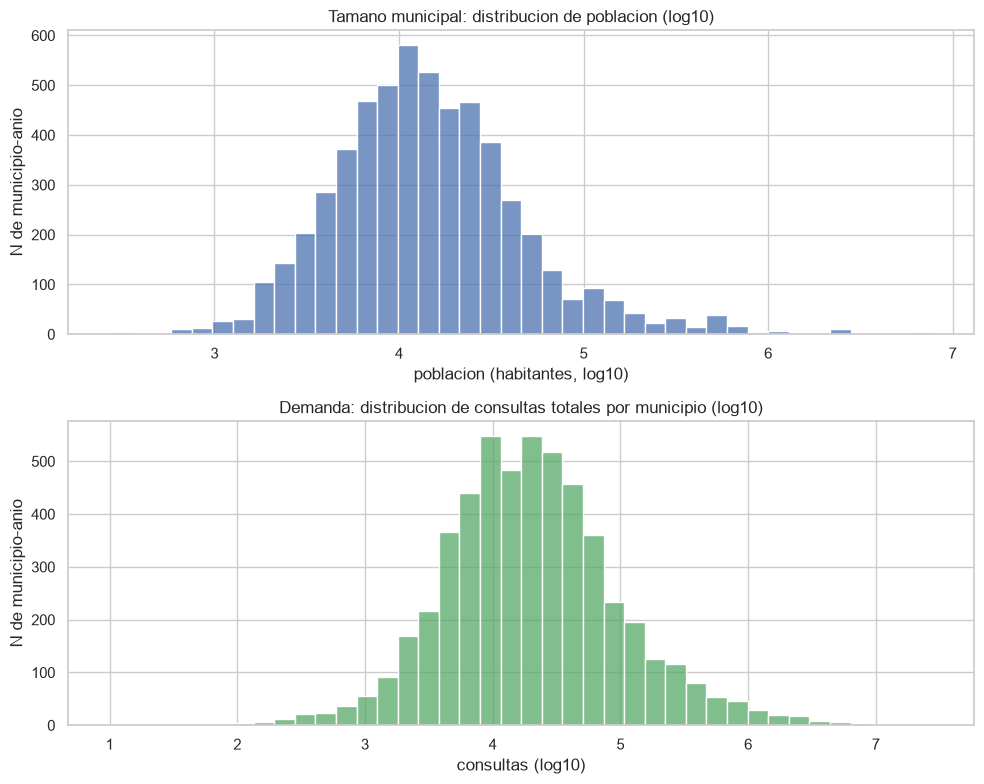

In [26]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))
sns.histplot(np.log10(df['poblacion'].replace(0, np.nan)).dropna(), bins=40, ax=axes[0], color='#4C72B0')
axes[0].set_title('Tamano municipal: distribucion de poblacion (log10)')
axes[0].set_xlabel('poblacion (habitantes, log10)')
axes[0].set_ylabel('N de municipio-anio')
sns.histplot(np.log10(df['consultas'].replace(0, np.nan)).dropna(), bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Demanda: distribucion de consultas totales por municipio (log10)')
axes[1].set_xlabel('consultas (log10)')
axes[1].set_ylabel('N de municipio-anio')
plt.tight_layout()
plt.show()

### 2.2 Indicadores por habitante y contexto

**Que muestra:** histograma de cada indicador normalizado (tasas por 1.000 hab, sedes por 10.000 hab), mas `pct_rural_disperso` y `banda_pob`.
**Como leerlo:** cada panel es una variable; la altura indica frecuencia. Las tasas usan la poblacion DANE como denominador.
**Que observar:** `consultas_1000hab` y `sedes_10k_hab` tienen **cola a la derecha** (unos pocos municipios ofrecen muchisimo servicio por habitante = prestadores-hub). `pct_rural_disperso` y `banda_pob` son mas planas porque son de contexto, no de oferta.

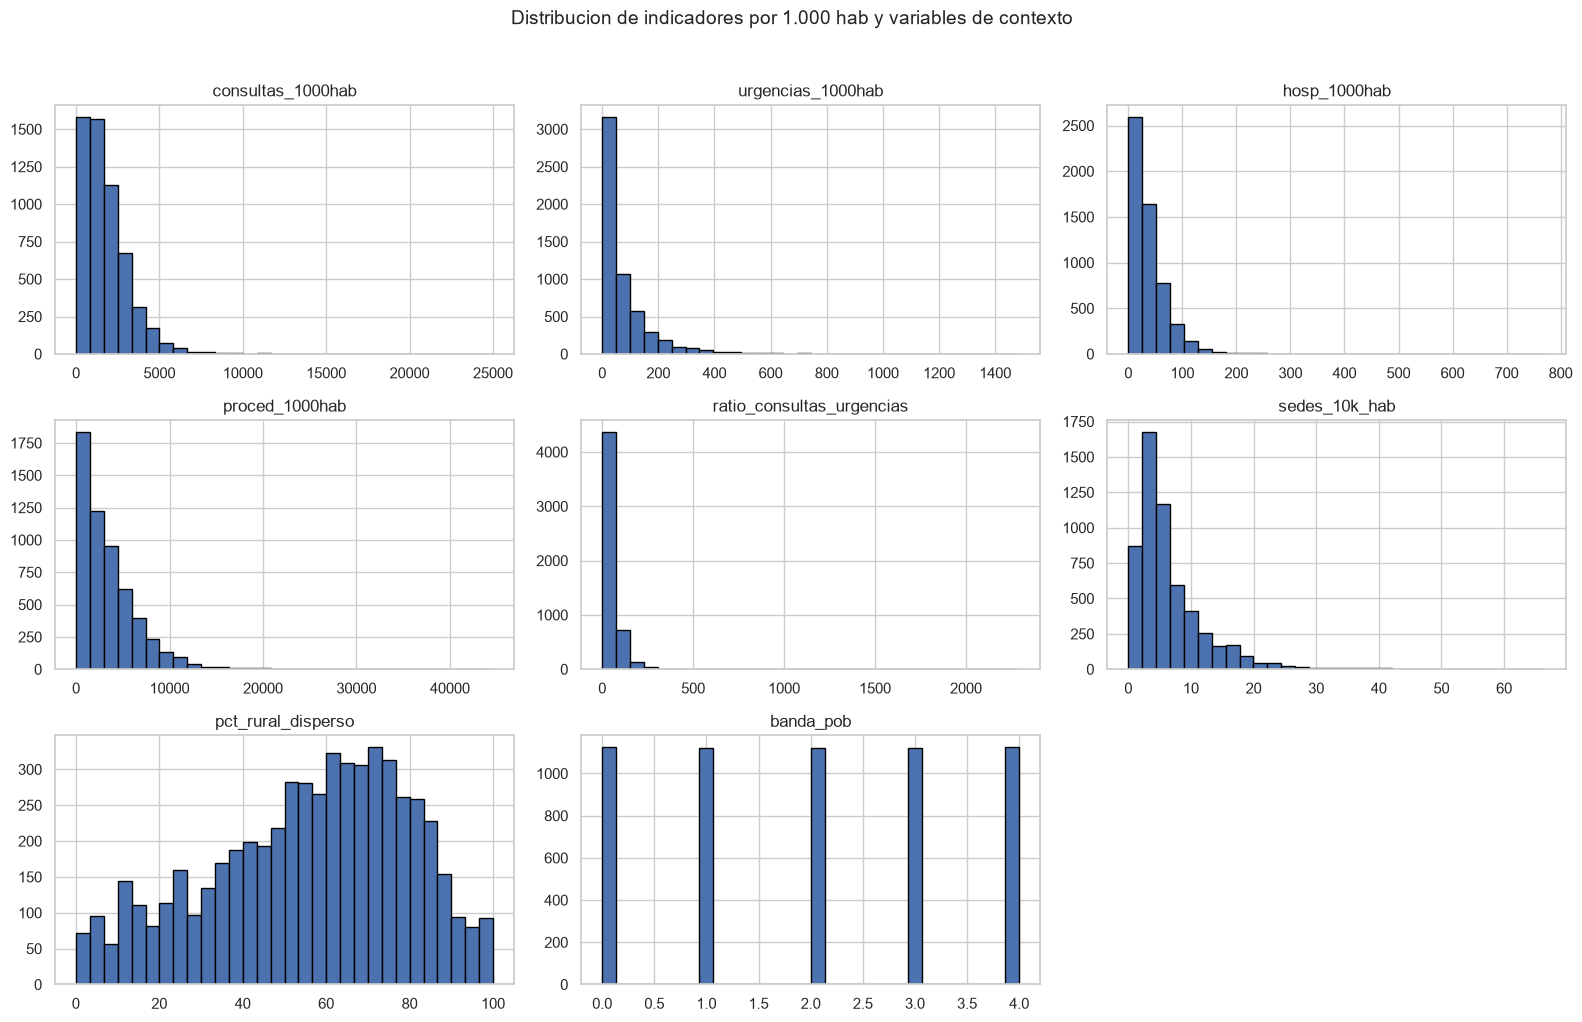

In [27]:
subset = ['consultas_1000hab', 'urgencias_1000hab', 'hosp_1000hab', 'proced_1000hab',
          'ratio_consultas_urgencias', 'sedes_10k_hab', 'pct_rural_disperso', 'banda_pob']

df[subset].hist(bins=30, figsize=(16, 10), edgecolor='black')
plt.suptitle('Distribucion de indicadores por 1.000 hab y variables de contexto', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

### 2.3 Dispersion y valores atipicos de las tasas

**Que muestra:** boxplots de las tasas por 1.000 hab (`consultas`, `urgencias`, `hosp`, `proced`) y de `sedes_10k_hab`.
**Como leerlo:** la caja abarca el 25%-75% (rango intercuartilico), la linea central es la **mediana** y cada punto es un valor atipico (fuera de 1,5 x IQR).
**Que observar:** muchos puntos por **encima** de la caja: municipios con oferta desproporcionada para su poblacion. Son justamente los que el modelo marca con `es_hub` y excluye del ranking de prioridad.

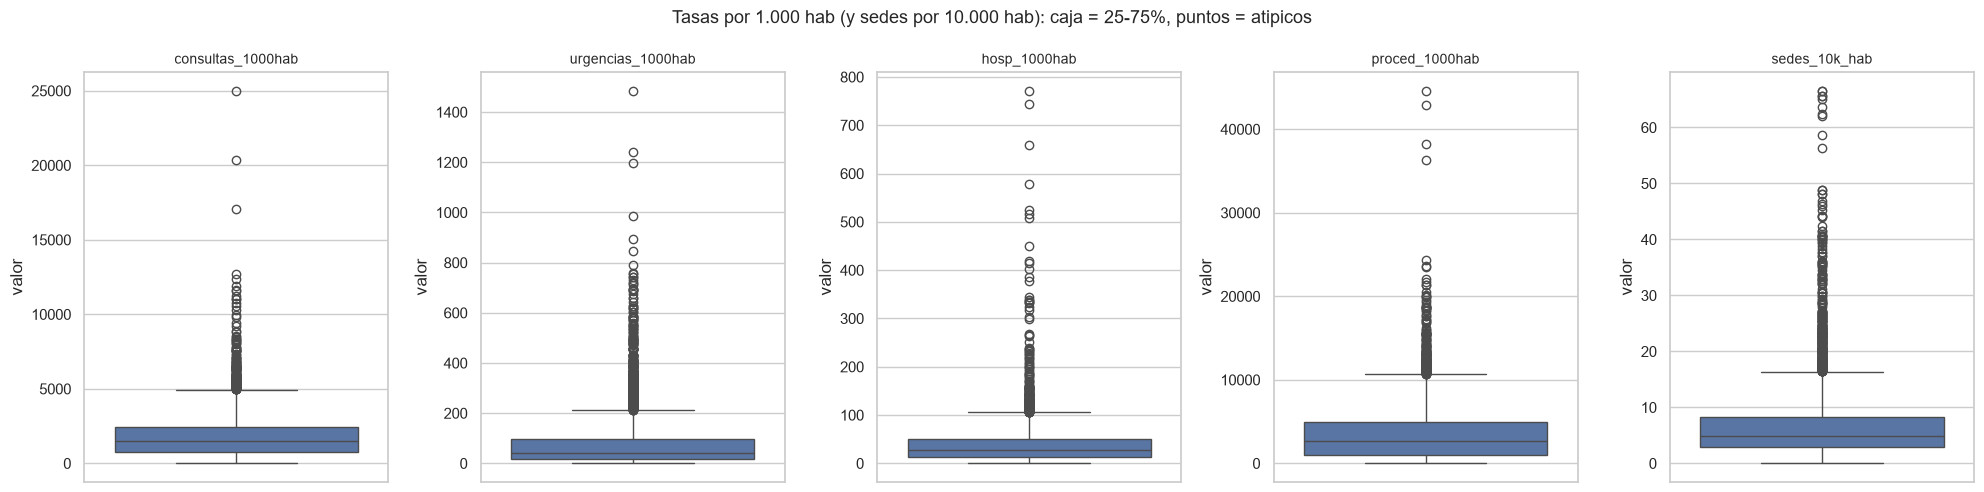

In [28]:
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for ax, col in zip(axes, ['consultas_1000hab', 'urgencias_1000hab', 'hosp_1000hab',
                          'proced_1000hab', 'sedes_10k_hab']):
    sns.boxplot(y=df[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=10)
    ax.set_ylabel('valor')
plt.suptitle('Tasas por 1.000 hab (y sedes por 10.000 hab): caja = 25-75%, puntos = atipicos', fontsize=13)
plt.tight_layout()
plt.show()

### 2.4 Balance de la clase objetivo

**Que muestra:** cuantos municipio-anio hay en cada clase de `prioridad_alta` (0 = no prioridad, 1 = prioridad).
**Como leerlo:** una barra por clase; la altura es el numero de registros.
**Que observar:** hay **~32% de positivos** (1.798 de 5.610): desbalance moderado. Las filas sin etiqueta (hubs y municipios sin poblacion) **no** aparecen porque `prioridad_alta` es nulo para ellas.

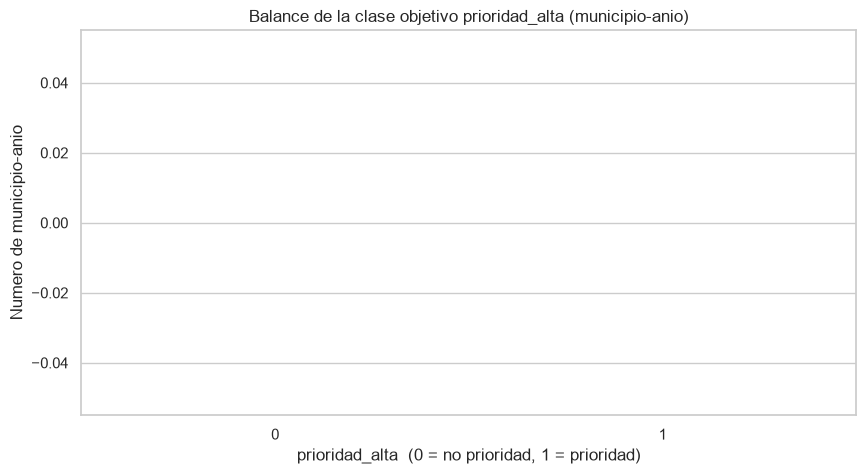

In [29]:
sns.countplot(data=df.dropna(subset=['prioridad_alta']), x='prioridad_alta', order=[0, 1],
              hue='prioridad_alta', legend=False, palette='viridis')
plt.title('Balance de la clase objetivo prioridad_alta (municipio-anio)')
plt.xlabel('prioridad_alta  (0 = no prioridad, 1 = prioridad)')
plt.ylabel('Numero de municipio-anio')
plt.show()

### 2.5 Composicion del panel

**Que muestra:** cuatro conteos del panel: por **anio** (`a_o`), por **quintil de poblacion** (`banda_pob`), por **presencia de RIPS** (`sin_rips`) y por **hub** (`es_hub`).
**Como leerlo:** cada barra es el numero de municipio-anio en esa categoria.
**Que observar:** el panel esta **balanceado** (1.122 municipios por cada anio); `sin_rips = True` en ~300 registros (57 municipios sin RIPS en ningun anio) y `es_hub = 1` en ~211.

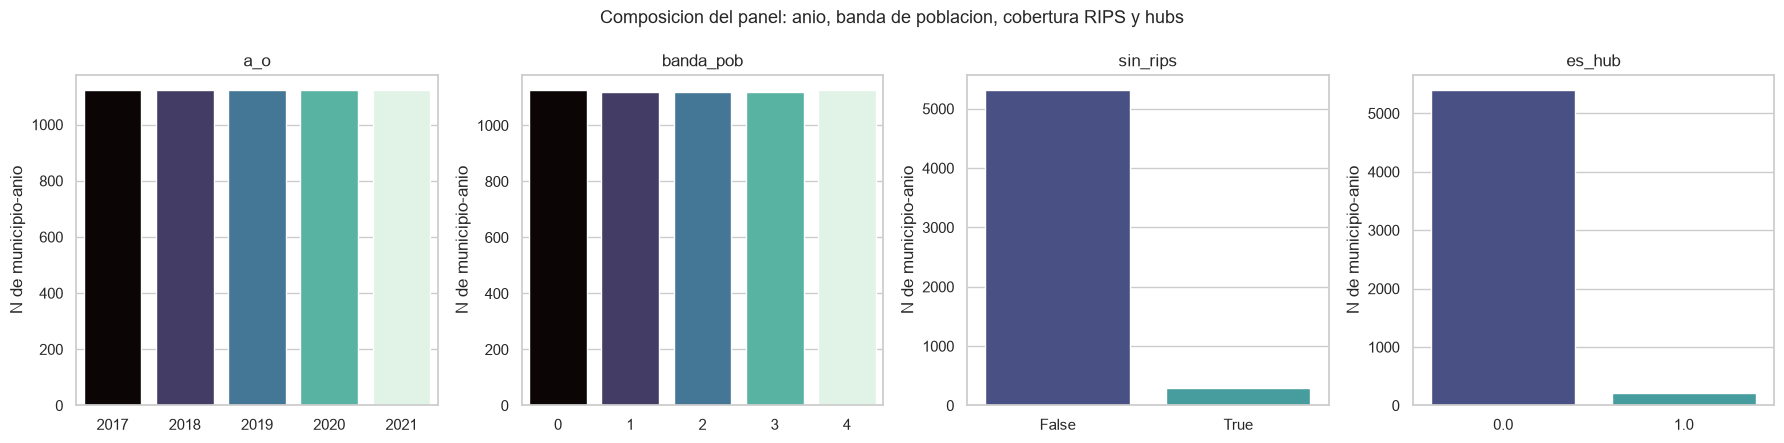

In [30]:
cats = ['a_o', 'banda_pob', 'sin_rips', 'es_hub']
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, col in zip(axes.ravel(), cats):
    sns.countplot(data=df, x=col, ax=ax, hue=col, legend=False,
                  order=sorted(df[col].dropna().unique()), palette='mako')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('N de municipio-anio')
plt.suptitle('Composicion del panel: anio, banda de poblacion, cobertura RIPS y hubs', fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 Evolucion temporal de las atenciones

**Que muestra:** total de **consultas**, **urgencias** y **hospitalizaciones** por anio (suma de los 1.122 municipios).
**Como leerlo:** una linea por tipo de atencion; el eje y esta en **millones** de atenciones.
**Que observar:** **2017** viene bajo (cobertura RIPS incompleta ese anio) y **2020** cae frente a 2019 por el efecto de la pandemia (COVID-19). Es una senal de calidad temporal a tener en cuenta.

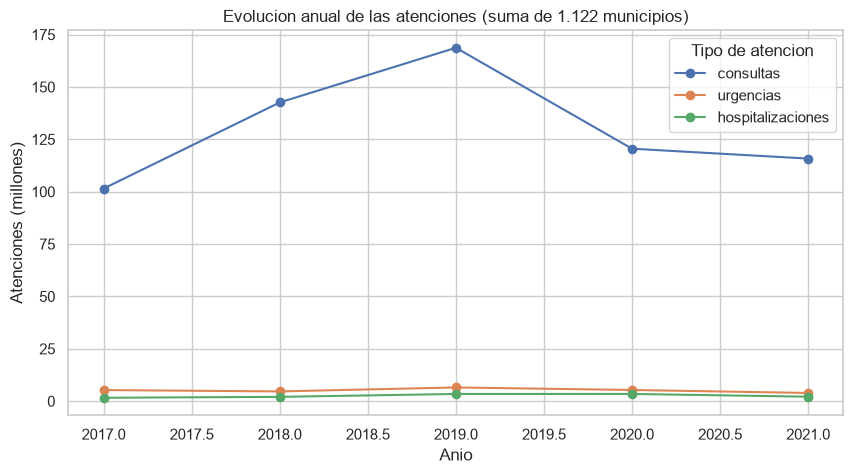

 a_o  consultas  urgencias  hospitalizaciones
2017  101499634    5286250            1603185
2018  142602150    4634015            2040992
2019  168705682    6536722            3420050
2020  120515613    5317997            3433422
2021  115797740    3898880            2121354


In [31]:
por_anio = df.groupby('a_o').agg(consultas=('consultas', 'sum'),
                                 urgencias=('urgencias', 'sum'),
                                 hospitalizaciones=('hospitalizaciones', 'sum')).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for c in ['consultas', 'urgencias', 'hospitalizaciones']:
    ax.plot(por_anio['a_o'], por_anio[c] / 1e6, marker='o', label=c)
ax.set_xlabel('Anio')
ax.set_ylabel('Atenciones (millones)')
ax.set_title('Evolucion anual de las atenciones (suma de 1.122 municipios)')
ax.legend(title='Tipo de atencion')
plt.show()
print(por_anio.to_string(index=False))

### 2.7 Correlacion entre variables del modelo

**Que muestra:** matriz de correlacion (Pearson) de 14 variables clave: poblacion, ruralidad, infraestructura, etnico, demanda por habitante y el target.
**Como leerlo:** **rojo** = correlacion positiva, **azul** = negativa; cada celda trae el coeficiente (-1 a 1). La diagonal vale 1.
**Que observar:** `consultas_1000hab` va en **contra** de `brecha_consultas` (menos atencion por habitante, mas brecha) y `poblacion` correlaciona con `n_sedes`. Sirve para detectar variables redundantes antes de modelar.

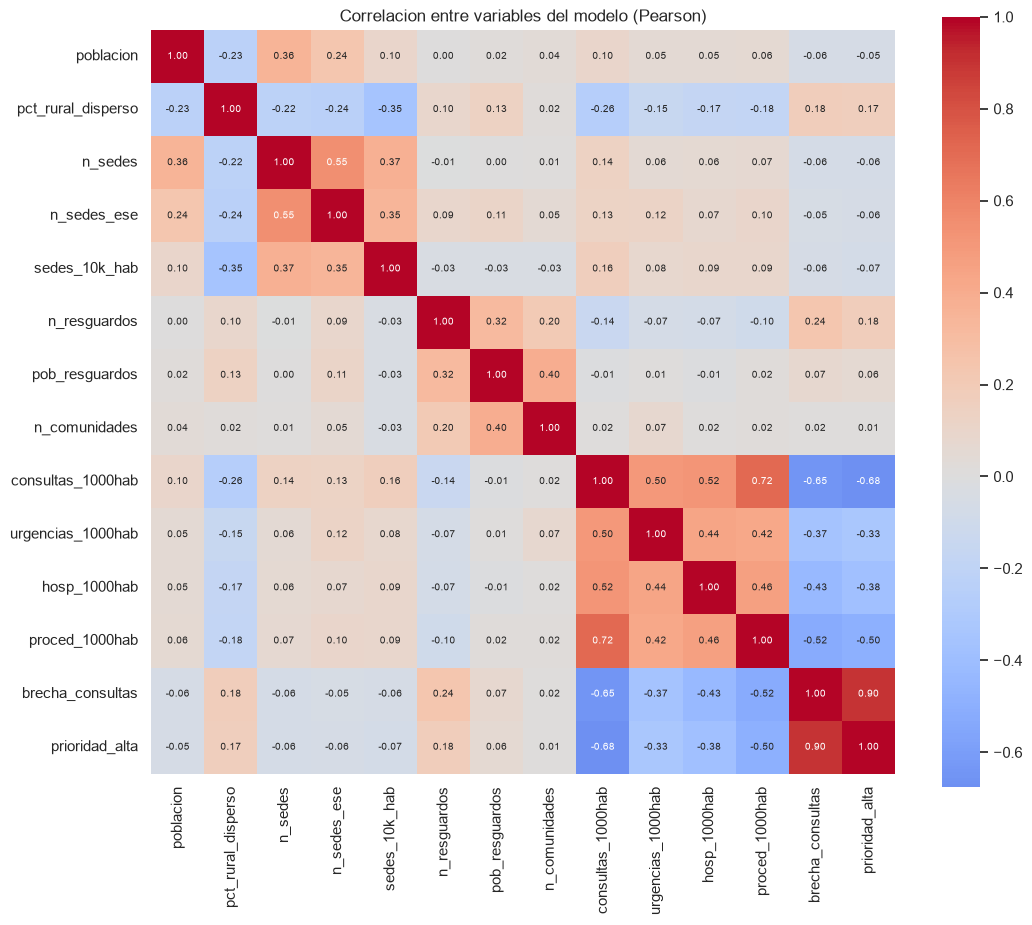

In [32]:
modelo_cols = ['poblacion', 'pct_rural_disperso', 'n_sedes', 'n_sedes_ese', 'sedes_10k_hab',
               'n_resguardos', 'pob_resguardos', 'n_comunidades',
               'consultas_1000hab', 'urgencias_1000hab', 'hosp_1000hab', 'proced_1000hab',
               'brecha_consultas', 'prioridad_alta']

plt.figure(figsize=(12, 10))
sns.heatmap(df[modelo_cols].corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 7}, square=True)
plt.title('Correlacion entre variables del modelo (Pearson)')
plt.show()

### 2.8 Relacion de cada capitulo CIE-10 con la brecha

**Que muestra:** correlacion de cada `pct_cap_X` (peso del capitulo CIE-10 en las atenciones) con `brecha_consultas`.
**Como leerlo:** barras a la **derecha** = el capitulo pesa mas donde hay mas brecha; a la **izquierda**, lo contrario. Valor 0 = sin relacion.
**Que observar:** suele haber correlacion positiva en capitulos tipicos de zonas dispersas/indigenas (infecciosas, materno-infantil) y negativa en capitulos que requieren mayor complejidad. Orientativo, no causal.

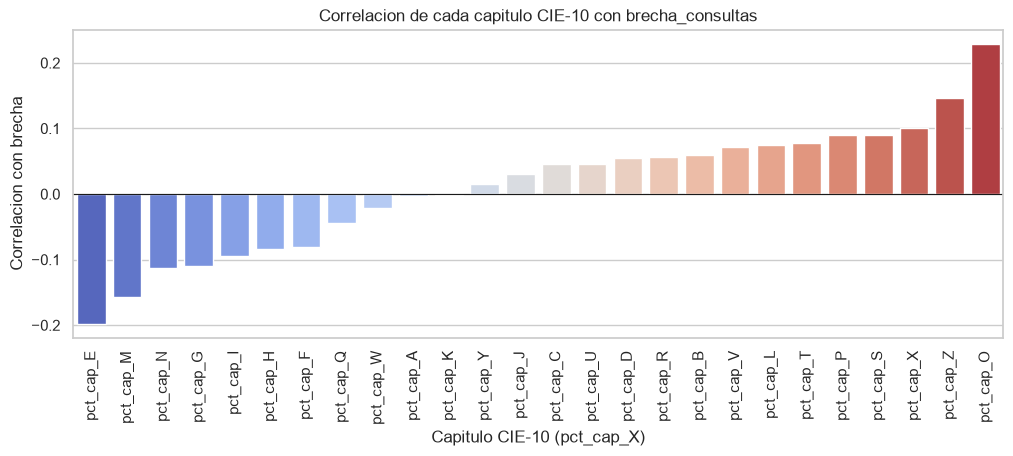

pct_cap_E   -0.198
pct_cap_M   -0.157
pct_cap_N   -0.112
pct_cap_G   -0.110
pct_cap_I   -0.095
pct_cap_H   -0.085
pct_cap_F   -0.081
pct_cap_Q   -0.045
pct_cap_W   -0.021
pct_cap_A   -0.004
pct_cap_K   -0.001
pct_cap_Y    0.015
pct_cap_J    0.030
pct_cap_C    0.045
pct_cap_U    0.046
pct_cap_D    0.055
pct_cap_R    0.056
pct_cap_B    0.060
pct_cap_V    0.072
pct_cap_L    0.075
pct_cap_T    0.078
pct_cap_P    0.090
pct_cap_S    0.090
pct_cap_X    0.100
pct_cap_Z    0.147
pct_cap_O    0.229


In [33]:
cap_cols = [c for c in df.columns if c.startswith('pct_cap_')]
corr_cap = df[cap_cols + ['brecha_consultas']].corr()['brecha_consultas'].drop('brecha_consultas').sort_values()

plt.figure(figsize=(12, 4))
sns.barplot(x=corr_cap.index, y=corr_cap.values, hue=corr_cap.index, legend=False, palette='coolwarm')
plt.axhline(0, color='k', lw=0.8)
plt.title('Correlacion de cada capitulo CIE-10 con brecha_consultas')
plt.xlabel('Capitulo CIE-10 (pct_cap_X)')
plt.ylabel('Correlacion con brecha')
plt.xticks(rotation=90)
plt.show()
print(corr_cap.round(3).to_string())

### 2.9 Poblacion vs demanda vs brecha (hubs en rojo)

**Que muestra:** dos diagramas de dispersion. **Izquierda:** `consultas_1000hab` contra `poblacion`. **Derecha:** `brecha_consultas` contra `poblacion`. Eje x en **log10**.
**Como leerlo:** cada punto es un municipio-anio; en **rojo** los marcados como `es_hub`.
**Que observar:** a la izquierda los puntos rojos se disparan (municipios pequenos con muchisima oferta per capita = cabeceras que atienden su area de influencia). A la derecha, la brecha se concentra en municipios pequenos **sin** hub. Justifica la correccion por pares y el flag `es_hub`.

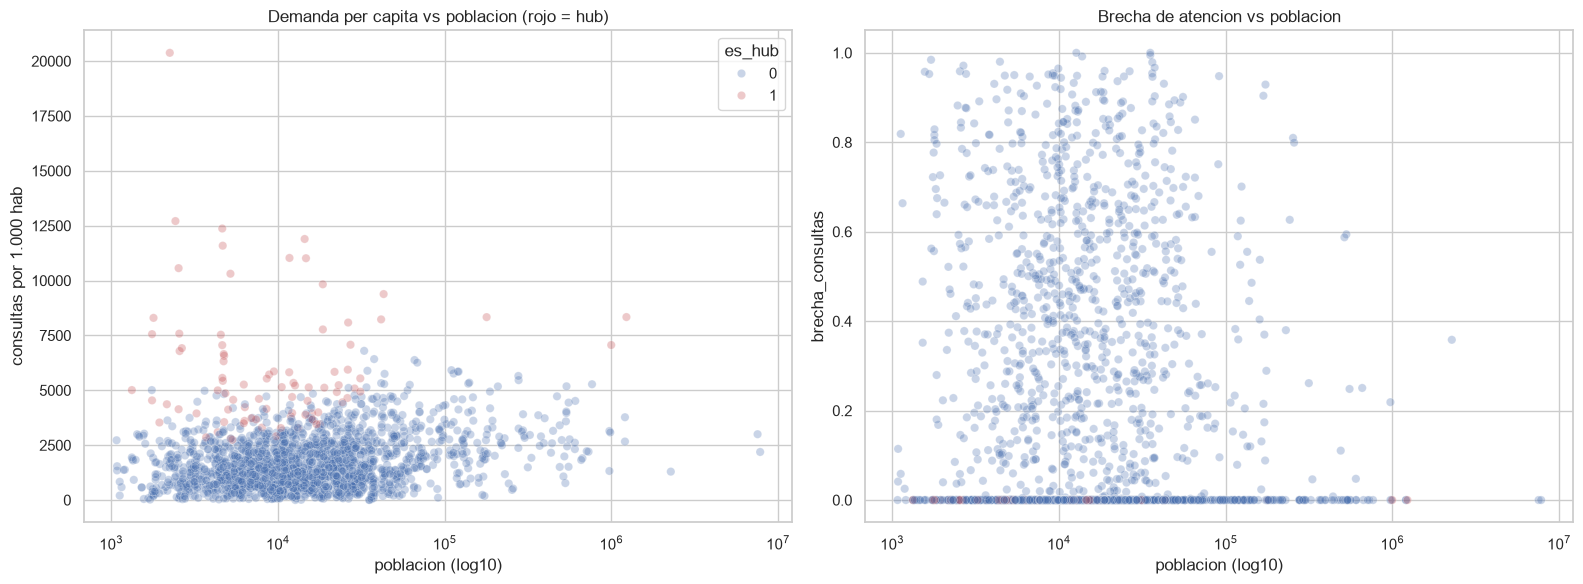

In [34]:
muestra = df[~df['sin_rips']].dropna(subset=['es_hub', 'brecha_consultas']).copy()
muestra['es_hub'] = muestra['es_hub'].astype(int)
if len(muestra) > 2000:
    muestra = muestra.sample(2000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.scatterplot(data=muestra, x='poblacion', y='consultas_1000hab', ax=axes[0], alpha=0.3,
                hue='es_hub', palette={0: '#4C72B0', 1: '#C44E52'})
axes[0].set_xscale('log')
axes[0].set_xlabel('poblacion (log10)')
axes[0].set_ylabel('consultas por 1.000 hab')
axes[0].set_title('Demanda per capita vs poblacion (rojo = hub)')
sns.scatterplot(data=muestra, x='poblacion', y='brecha_consultas', ax=axes[1], alpha=0.3,
                hue='es_hub', palette={0: '#4C72B0', 1: '#C44E52'}, legend=False)
axes[1].set_xscale('log')
axes[1].set_xlabel('poblacion (log10)')
axes[1].set_ylabel('brecha_consultas')
axes[1].set_title('Brecha de atencion vs poblacion')
plt.tight_layout()
plt.show()

### 2.10 Distribucion del target y umbral de prioridad

**Que muestra:** histograma de `brecha_consultas` con una linea roja en el **percentil 66**, que es el umbral usado para definir `prioridad_alta`.
**Como leerlo:** 0 = el municipio atiende al nivel de sus pares (misma banda de poblacion); 1 = deficit maximo de atencion.
**Que observar:** una masa grande cerca de **0** (municipios que ya alcanzan el benchmark de sus pares) y una cola hacia **1** (los que se priorizan). La forma no es simetrica: hay mas municipios "bien atendidos" que "muy deficitarios".

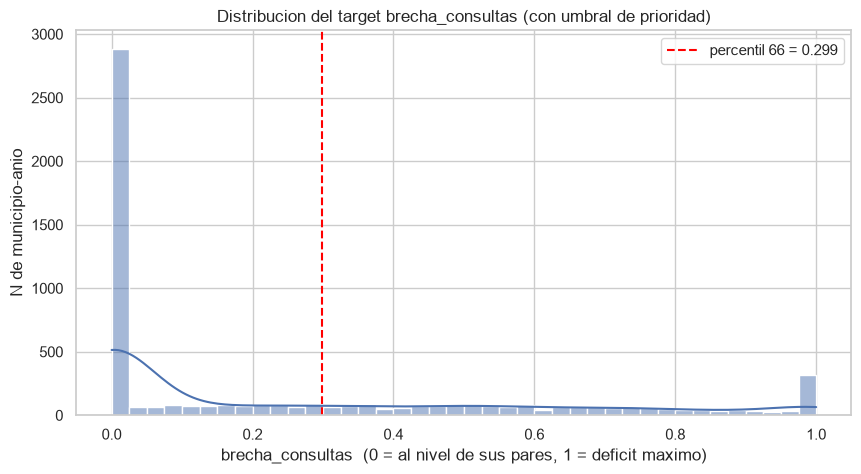

In [35]:
umbral = df['brecha_consultas'].quantile(0.66)
sns.histplot(df['brecha_consultas'].dropna(), bins=40, kde=True, color='#4C72B0')
plt.axvline(umbral, color='red', linestyle='--', label='percentil 66 = %.3f' % umbral)
plt.title('Distribucion del target brecha_consultas (con umbral de prioridad)')
plt.xlabel('brecha_consultas  (0 = al nivel de sus pares, 1 = deficit maximo)')
plt.ylabel('N de municipio-anio')
plt.legend()
plt.show()

## 3. Calidad de datos

In [36]:
nulos = df.isna().sum()
print('Valores nulos por columna:')
if nulos.any():
    print(nulos[nulos > 0].to_string())
else:
    print('  (ninguno)')

print()
print('Filas duplicadas:', df.duplicated().sum())
print('Llaves duplicadas (cod_mpio + a_o):', df.duplicated(['cod_mpio', 'a_o']).sum())

Valores nulos por columna:
pct_cap_A                    300
pct_cap_B                    295
pct_cap_C                    300
pct_cap_D                    285
pct_cap_E                    295
pct_cap_F                    290
pct_cap_G                    295
pct_cap_H                    295
pct_cap_I                    290
pct_cap_J                    285
pct_cap_K                    290
pct_cap_L                    295
pct_cap_M                    290
pct_cap_N                    300
pct_cap_O                    290
pct_cap_P                    325
pct_cap_Q                    310
pct_cap_R                    290
pct_cap_S                    285
pct_cap_T                    290
pct_cap_U                    350
pct_cap_V                    525
pct_cap_W                    310
pct_cap_X                    335
pct_cap_Y                    320
pct_cap_Z                    285
consultas_1000hab              5
urgencias_1000hab              5
hosp_1000hab                   5
proced_1000hab  

In [37]:
resumen = []
for col in df.select_dtypes(include=[np.number]).columns:
    serie = df[col].dropna()
    if serie.empty:
        continue
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((serie < li) | (serie > ls)).sum())
    resumen.append((col, n_out, round(n_out / len(serie) * 100, 2), round(li, 2), round(ls, 2)))

outliers = pd.DataFrame(resumen, columns=['columna', 'n_outliers', 'pct', 'lim_inf', 'lim_sup'])
print('Outliers por el metodo IQR (1.5):')
outliers.sort_values('n_outliers', ascending=False).reset_index(drop=True)

Outliers por el metodo IQR (1.5):


,columna,n_outliers,pct,lim_inf,lim_sup
0,pob_resguardos,1340,23.89,0.00,0.00
1,n_resguardos,1340,23.89,0.00,0.00
2,n_comunidades,930,16.58,0.00,0.00
3,n_sedes,750,13.37,-20.50,39.50
4,urgencias,733,13.07,-2395.00,4397.00
5,consultas,713,12.71,-54571.75,106910.25
6,atenciones_total,681,12.14,-172381.00,332897.00
7,hospitalizaciones,668,11.91,-1153.88,2235.12
8,pct_cap_Y,665,12.57,-0.17,0.48
9,procedimientos,655,11.68,-117526.62,220062.38


In [38]:
conteo = df['prioridad_alta'].value_counts(dropna=False)
porcentaje = (conteo / len(df) * 100).round(2)
print('Balance de prioridad_alta:')
print(pd.DataFrame({'conteo': conteo, 'porcentaje': porcentaje}).to_string())
print()
print('es_hub   :', df['es_hub'].value_counts(dropna=False).to_dict())
print('sin_rips :', df['sin_rips'].value_counts(dropna=False).to_dict())
print()
suma4 = df[['consultas', 'procedimientos', 'urgencias', 'hospitalizaciones']].sum(axis=1)
print('atenciones_total == suma de 4 tipos:', bool((df['atenciones_total'] == suma4).all()))
pct = df.filter(like='pct_cap_')
print('pct_cap fuera de 0-100            :', int(((pct < 0) | (pct > 100)).sum().sum()))
print('poblacion <= 0 (filas)            :', int((df['poblacion'] <= 0).sum()))
print('consultas == 0 con RIPS presentes :', int(((df['consultas'] == 0) & (~df['sin_rips'])).sum()))

Balance de prioridad_alta:
                conteo  porcentaje
prioridad_alta                    
0.0               3596       64.10
1.0               1798       32.05
NaN                216        3.85

es_hub   : {0.0: 5394, 1.0: 211, nan: 5}
sin_rips : {False: 5310, True: 300}

atenciones_total == suma de 4 tipos: True
pct_cap fuera de 0-100            : 0
poblacion <= 0 (filas)            : 5
consultas == 0 con RIPS presentes : 3


In [39]:
print('Municipios:', df['cod_mpio'].nunique(), '| Departamentos:', df['cod_dpto'].nunique(),
      '| Anios:', sorted(df['a_o'].unique()))
print('Panel completo (municipios x anios):', len(df) == df['cod_mpio'].nunique() * df['a_o'].nunique())
print()
print('Registros con poblacion = 0:')
print(df[df['poblacion'] <= 0][['cod_mpio', 'nom_mpio', 'a_o', 'poblacion']].to_string(index=False))
print()
print('Municipios sin RIPS en ningun anio:', int(df.groupby('cod_mpio')['sin_rips'].all().sum()))
print()
print('Registros con consultas = 0 pero RIPS presente:')
print(df[(df['consultas'] == 0) & (~df['sin_rips'])][['cod_mpio', 'nom_mpio', 'a_o', 'atenciones_total']].to_string(index=False))

Municipios: 1122 | Departamentos: 33 | Anios: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]
Panel completo (municipios x anios): True

Registros con poblacion = 0:
cod_mpio              nom_mpio  a_o  poblacion
   27493 NUEVO BELÉN DE BAJIRÁ 2017        0.0
   27493 NUEVO BELÉN DE BAJIRÁ 2018        0.0
   27493 NUEVO BELÉN DE BAJIRÁ 2019        0.0
   27493 NUEVO BELÉN DE BAJIRÁ 2020        0.0
   27493 NUEVO BELÉN DE BAJIRÁ 2021        0.0

Municipios sin RIPS en ningun anio: 57

Registros con consultas = 0 pero RIPS presente:
cod_mpio     nom_mpio  a_o  atenciones_total
   85001        YOPAL 2021             47452
   85125 HATO COROZAL 2020               117
   85440   VILLANUEVA 2018              1010


## 4. Conclusiones

- El dataset tiene **5.610 filas (1.122 municipios x 2017-2021) y 57 columnas**; la llave `cod_mpio` + `a_o` no tiene duplicados y el panel esta completo.
- Los nulos son **estructurales**, no aleatorios: `pct_cap_*` (capitulos CIE-10 sin atenciones), `ratio_consultas_urgencias` (urgencias = 0) y `prioridad_alta` (hubs + filas sin poblacion).
- La clase `prioridad_alta` esta **moderadamente desbalanceada (~33% positivos)**: conviene reportar metricas macro / F1 y no solo accuracy.
- Los outliers corresponden a municipios grandes y, sobre todo, a los **hubs** (prestadores que atienden su area de influencia); ya se marcan con `es_hub` y se excluyen del ranking.
- Anomalias puntuales: `poblacion = 0` (Nuevo Belen de Bajira, 27493), `consultas = 0` con RIPS (Yopal 2021, Hato Corozal 2020, Villanueva 2018), baja cobertura RIPS en 2017 y caida en 2020 (COVID).
- **Fuga de informacion:** las variables derivadas de RIPS (`*_1000hab`, `pct_cap_*`, `brecha_*`) NO deben usarse como features al modelar; usar solo contexto (poblacion, ruralidad, REPS, etnico).
- Siguiente fase: modelado con features de contexto y `prioridad_alta` como objetivo.